Fold 1: MSE=0.0451, MAE=0.1581, R²=0.5651


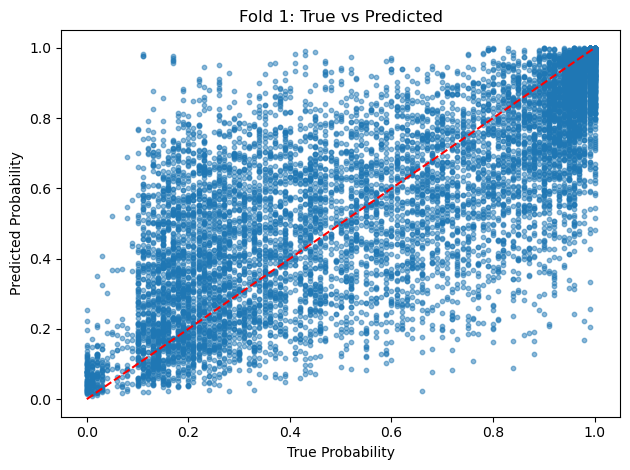

Fold 2: MSE=0.0468, MAE=0.1634, R²=0.5495


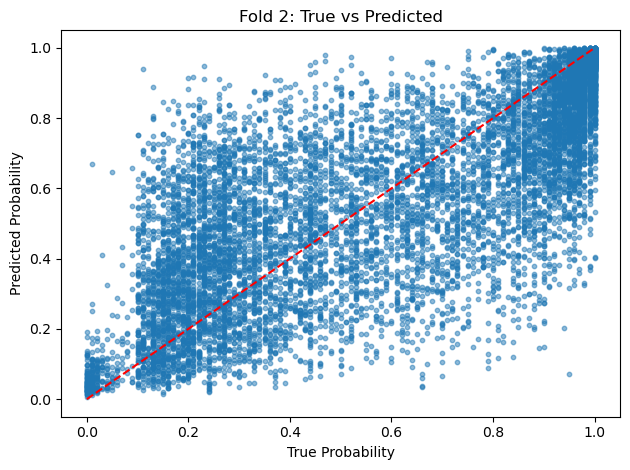

Fold 3: MSE=0.0459, MAE=0.1599, R²=0.5587


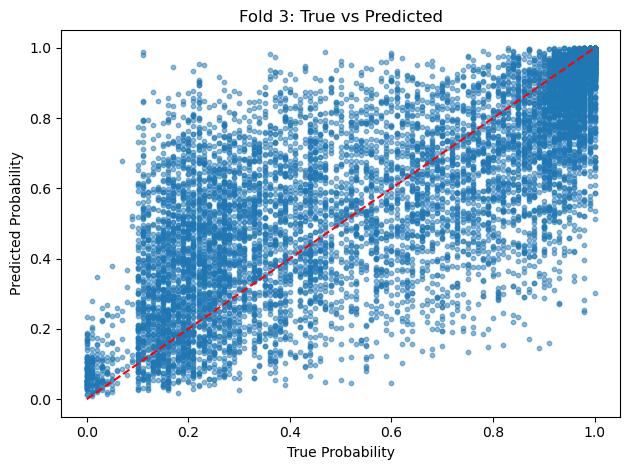

In [1]:
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with open("fold_val_results.pkl", "rb") as f:
    fold_results = pickle.load(f)

for fold_num, fold in fold_results.items():
    labels = fold["all_labels"]
    preds = fold["all_preds"]
    mse = mean_squared_error(labels, preds)
    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)
    print(f"Fold {fold_num}: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    plt.figure()
    plt.scatter(labels, preds, alpha=0.5, s=10)
    plt.xlabel("True Probability")
    plt.ylabel("Predicted Probability")
    plt.title(f"Fold {fold_num}: True vs Predicted")
    plt.plot([0, 1], [0, 1], 'r--')
    plt.tight_layout()
    plt.show()

Fold 1: MSE=0.0451, MAE=0.1581, R²=0.5651


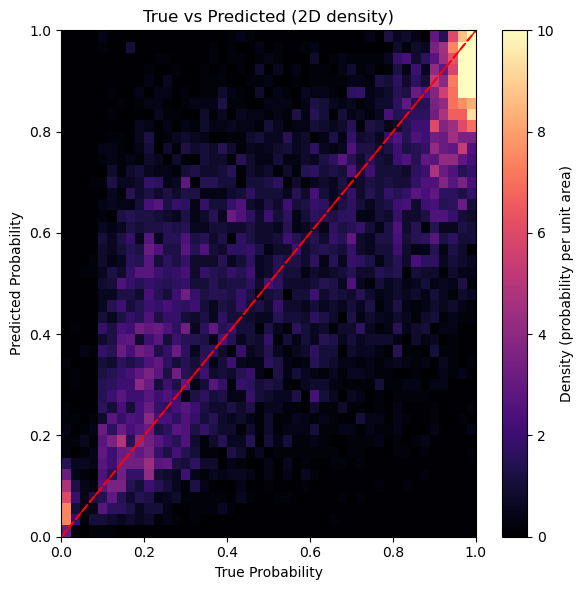

Fold 2: MSE=0.0468, MAE=0.1634, R²=0.5495


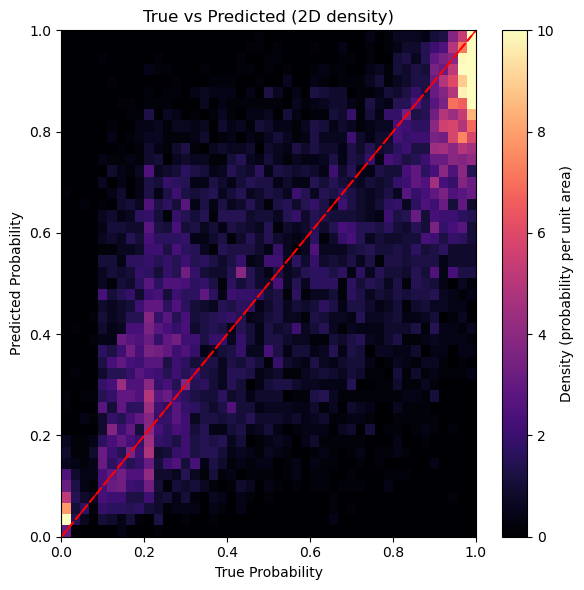

Fold 3: MSE=0.0459, MAE=0.1599, R²=0.5587


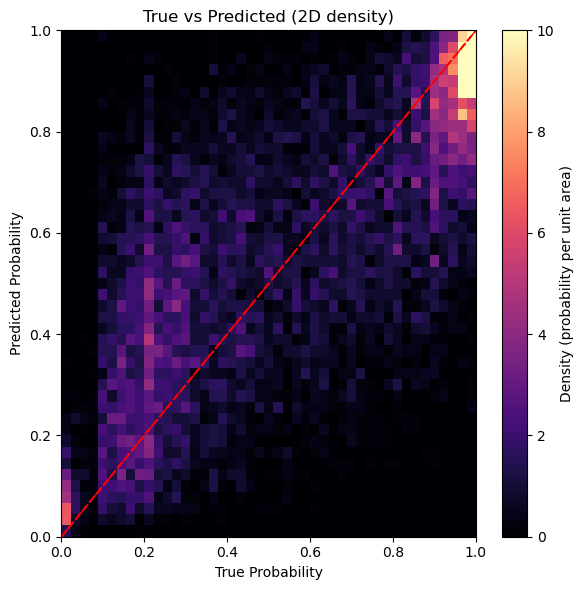

In [2]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

with open("fold_val_results.pkl", "rb") as f:
    fold_results = pickle.load(f)

for fold_num, fold in fold_results.items():
    labels = fold["all_labels"]
    preds = fold["all_preds"]
    mse = mean_squared_error(labels, preds)
    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)
    print(f"Fold {fold_num}: MSE={mse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    

    # labels, preds already defined
    fig, ax = plt.subplots(figsize=(6,6))

    bins = 45
    H, xedges, yedges = np.histogram2d(labels, preds, bins=bins, range=[[0,1],[0,1]], density=True)
    # use only positive values for LogNorm
    # linear normalization (not log)
    pcm = ax.pcolormesh(xedges, yedges, H.T, cmap='magma', norm=mcolors.Normalize(vmin=0, vmax=10))
    ax.plot([0,1],[0,1],'r--', lw=1)
    ax.set_xlabel("True Probability")
    ax.set_ylabel("Predicted Probability")
    ax.set_title("True vs Predicted (2D density)")
    plt.colorbar(pcm, ax=ax, label='Density (probability per unit area)')

    plt.plot([0, 1], [0, 1], 'r--')
    plt.tight_layout()
    plt.show()

In [3]:
fold_num = list(fold_results.keys())[0]
labels = fold_results[fold_num]["all_labels"]
preds = fold_results[fold_num]["all_preds"]
for i in range(10):
    print(f"Sample {i}: True={labels[i]:.3f}, Pred={preds[i]:.3f}")

Sample 0: True=1.000, Pred=0.904
Sample 1: True=0.980, Pred=0.983
Sample 2: True=0.980, Pred=0.949
Sample 3: True=1.000, Pred=0.893
Sample 4: True=0.980, Pred=0.737
Sample 5: True=0.970, Pred=0.975
Sample 6: True=0.970, Pred=0.922
Sample 7: True=0.970, Pred=0.914
Sample 8: True=0.970, Pred=0.863
Sample 9: True=0.970, Pred=0.897


In [5]:
fold_results.keys()

dict_keys([1, 2, 3])

In [7]:
import pandas as pd

df = pd.read_csv("fold_models/training_curves_per_fold.csv")

df

,fold,epoch,train_loss,val_loss
0,1,1,0.673380,0.612546
1,1,2,0.607340,0.583344
2,1,3,0.578788,0.567053
3,1,4,0.564266,0.555020
4,1,5,0.553591,0.546202
...,...,...,...,...
145,3,46,0.487100,0.558411
146,3,47,0.484140,0.542764
147,3,48,0.484810,0.543583
148,3,49,0.483691,0.544188


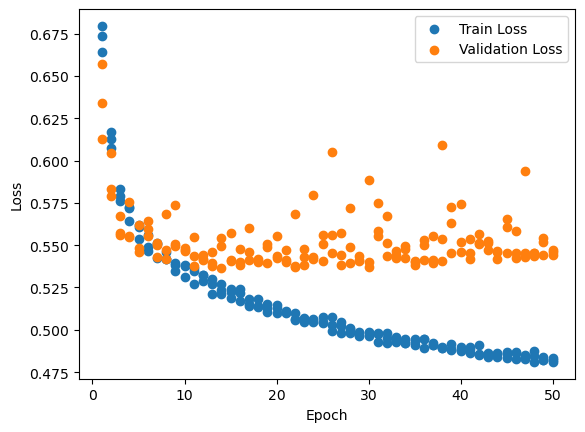

In [8]:
plt.scatter(df['epoch'], df['train_loss'], label='Train Loss')
plt.scatter(df['epoch'], df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()